In [ ]:
import numpy as np
import pandas as pd
import missingno as msno
%matplotlib inline

In [ ]:
import seaborn as sns
from scipy.stats import f_oneway

In [ ]:
from sklearn.datasets import make_classification
from sklearn.metrics import (precision_recall_curve,
                             PrecisionRecallDisplay)
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
import statistics

In [ ]:
from sklearn.metrics import f1_score
from sklearn import metrics

In [ ]:

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from matplotlib import figure
from scipy.stats import shapiro
from scipy.stats import pearsonr
import pylab as py
from sklearn.linear_model import LogisticRegression

In [ ]:
import statsmodels.api as sm
from statsmodels.nonparametric.kernel_regression import KernelReg
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.metrics import mean_squared_error

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


[pokemon-database](https://www.kaggle.com/datasets/mrdew25/pokemon-database)

In [ ]:
projeto= pd.read_csv('projeto.csv')

In [ ]:
pd.set_option('display.max_rows', 1080)
pd.set_option('display.max_columns', 50)

In [ ]:
projeto.head(5)

,Building Address,Latitude,Longitude,City,Municipality,Date,Building Age,Price per m2,Number of apartments,Population Total,Pet Policy,Trash gathering interval/Days,Trash collected in kg
0,"Viela de Viana, 381",-17.74431,-48.62789,Sao_Paulo,Caldas Novas,2021-11-17T17:52:10,52,22435,32,128,True,2,596.73
1,"Área Lima, 67",-22.92306,-53.13722,Sao_Paulo,Loanda,2023-03-18T11:25:02,40,13805,37,222,True,2,580.17
2,"Via Mariana Mendes, 9",-22.45667,-47.53028,Sao_Paulo,Santa Gertrudes,2022-02-24T16:13:16,50,23121,25,50,True,1,42.78
3,"Sítio Fogaça, 815",-29.29750,-51.50361,Sao_Paulo,Carlos Barbosa,2022-08-01T06:05:01,30,28804,25,50,True,2,139.94
4,"Chácara Daniela Duarte, 24",-20.25333,-43.80139,Sao_Paulo,Itabirito,2021-11-12T10:14:18,61,22596,26,104,True,2,353.36


In [ ]:
list(projeto.columns)

['Building Address',
 'Latitude',
 'Longitude',
 'City',
 'Municipality',
 'Date',
 'Building Age',
 'Price per m2',
 'Number of apartments',
 'Population Total',
 'Pet Policy',
 'Trash gathering interval/Days',
 'Trash collected in kg']

In [ ]:
projeto.describe()

,Latitude,Longitude,Building Age,Price per m2,Number of apartments,Population Total,Trash gathering interval/Days,Trash collected in kg
count,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000,288.000000
mean,-21.339127,-46.525451,46.208333,18669.722222,29.180556,109.055556,2.572917,473.046354
std,5.737397,5.433284,14.394334,5435.694645,7.283366,55.238448,0.977925,379.473016
min,-29.297500,-53.137220,0.000000,4964.000000,7.000000,-43.000000,1.000000,-278.980000
25%,-25.427780,-51.503610,37.000000,15388.000000,25.000000,71.250000,2.000000,206.450000
50%,-22.456670,-48.296940,46.000000,19243.500000,29.000000,104.000000,2.000000,378.285000
75%,-19.762500,-42.981940,57.000000,22656.750000,34.000000,140.000000,3.000000,616.582500
max,-8.053890,-34.881110,86.000000,32138.000000,51.000000,296.000000,5.000000,1818.380000


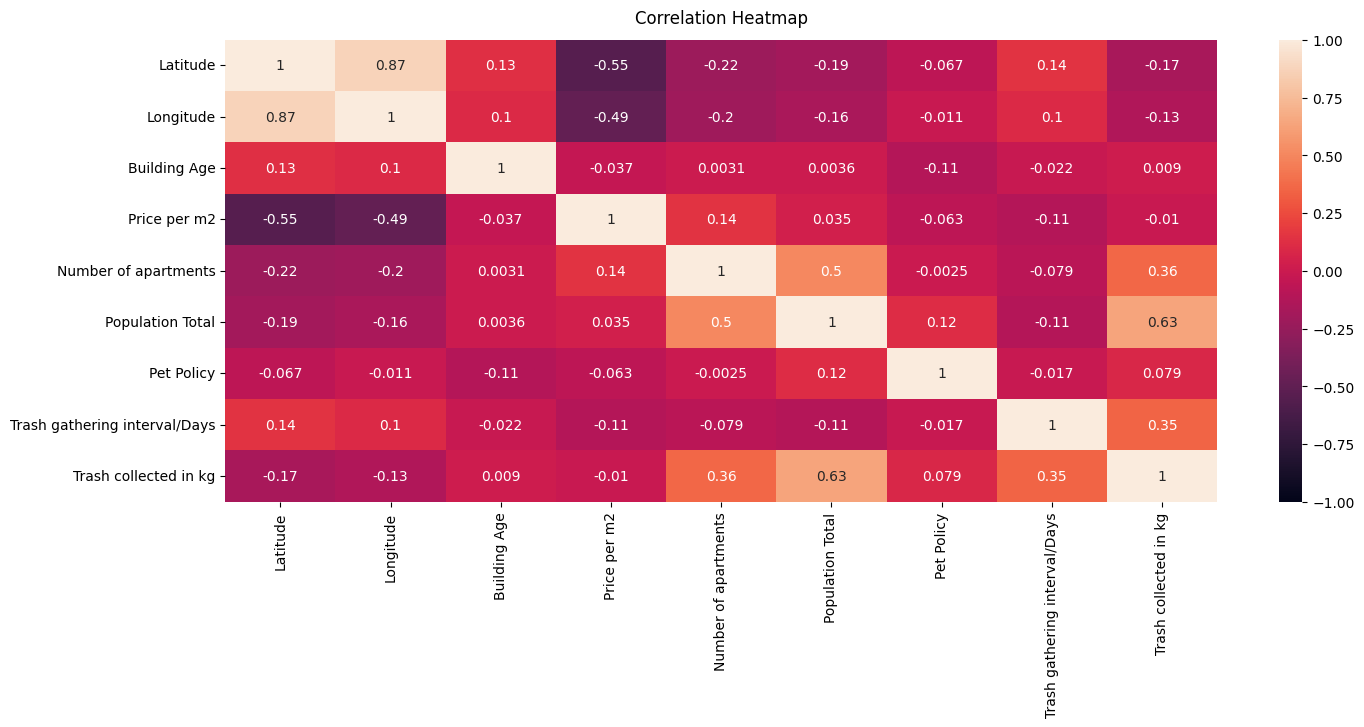

In [ ]:
plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(projeto.corr(), vmin=-1, vmax=1, annot=True)
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12}, pad=12);

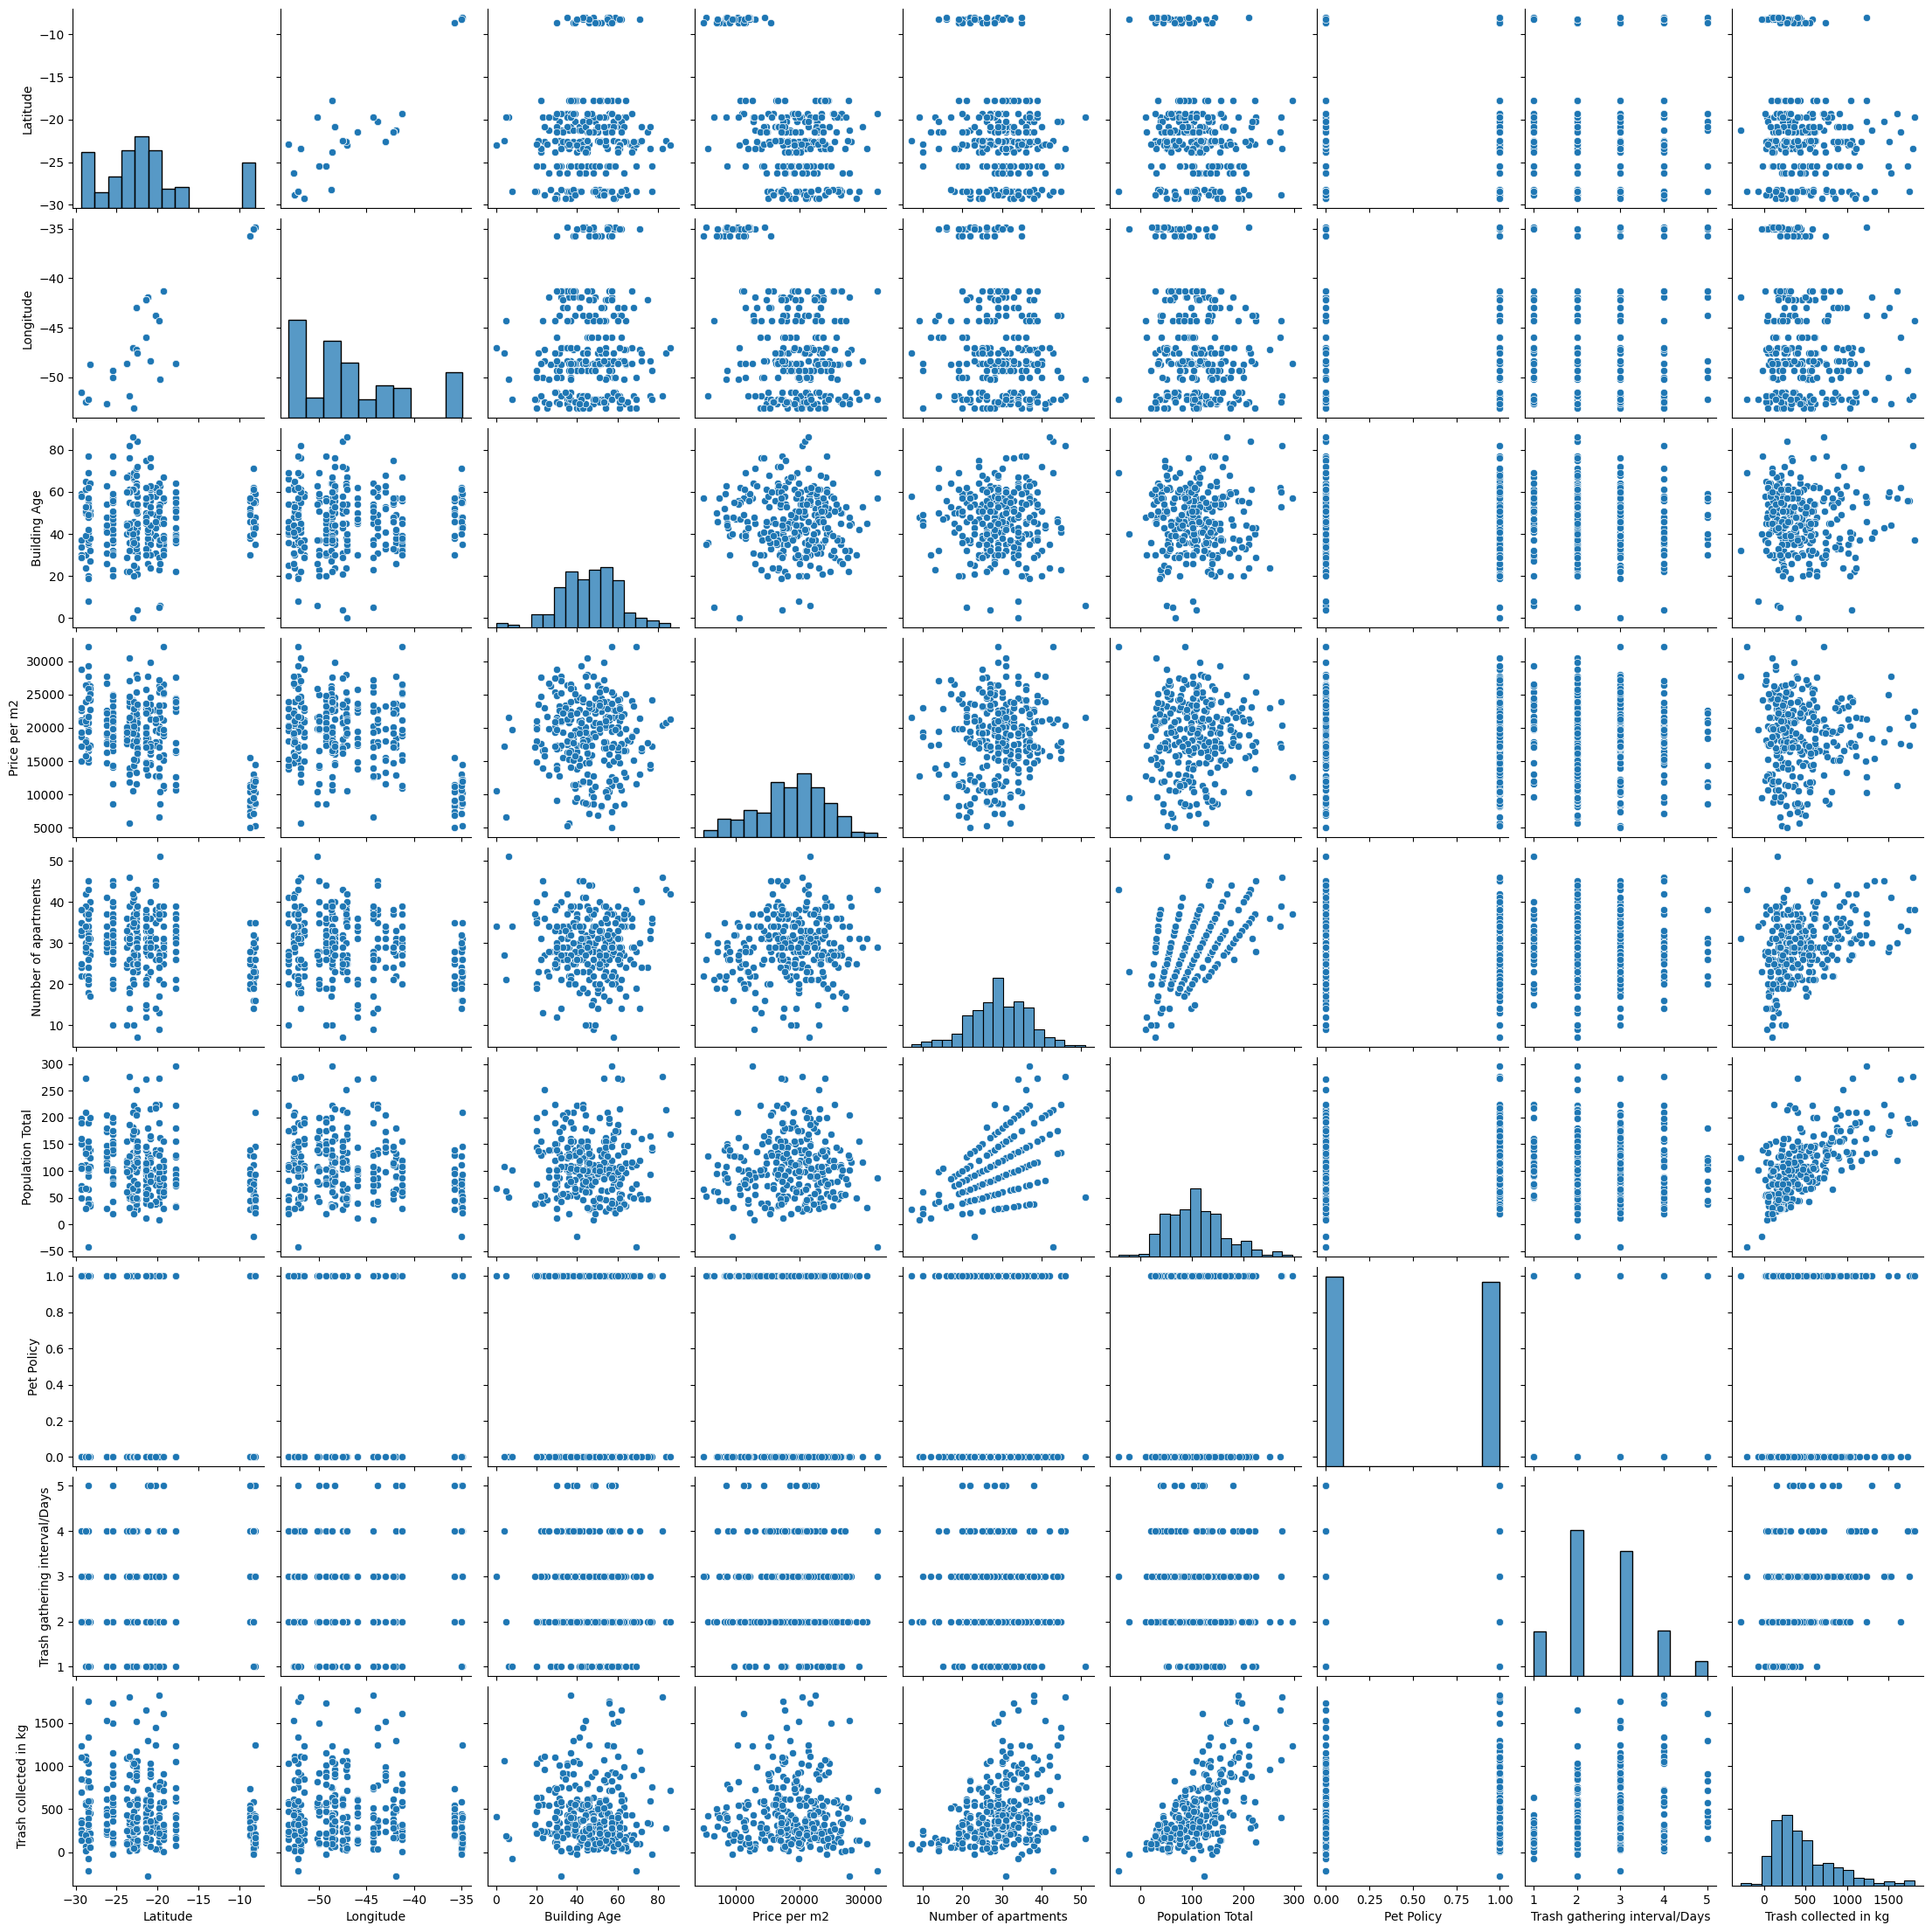

In [ ]:
sns.pairplot(projeto)

# **Teste de Hipótese 1**

A Hipótese é se um edifício tem mais pessoas ele tambem vai diretamente produzir mais lixo

In [ ]:
dep = 'Trash collected in kg'
indep = 'Population Total'

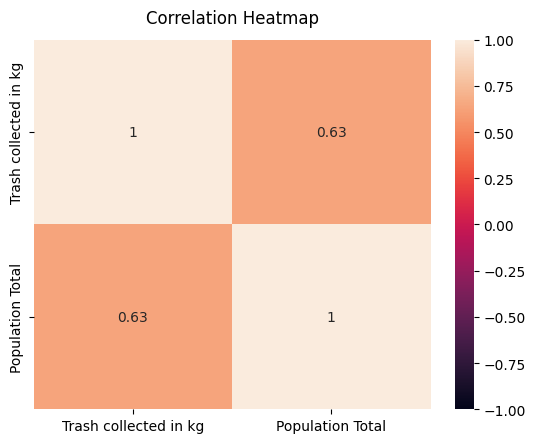

In [ ]:
heatmap = sns.heatmap(projeto[[dep,indep]].corr(), vmin=-1, vmax=1, annot=True)
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12}, pad=12);

<Axes: >

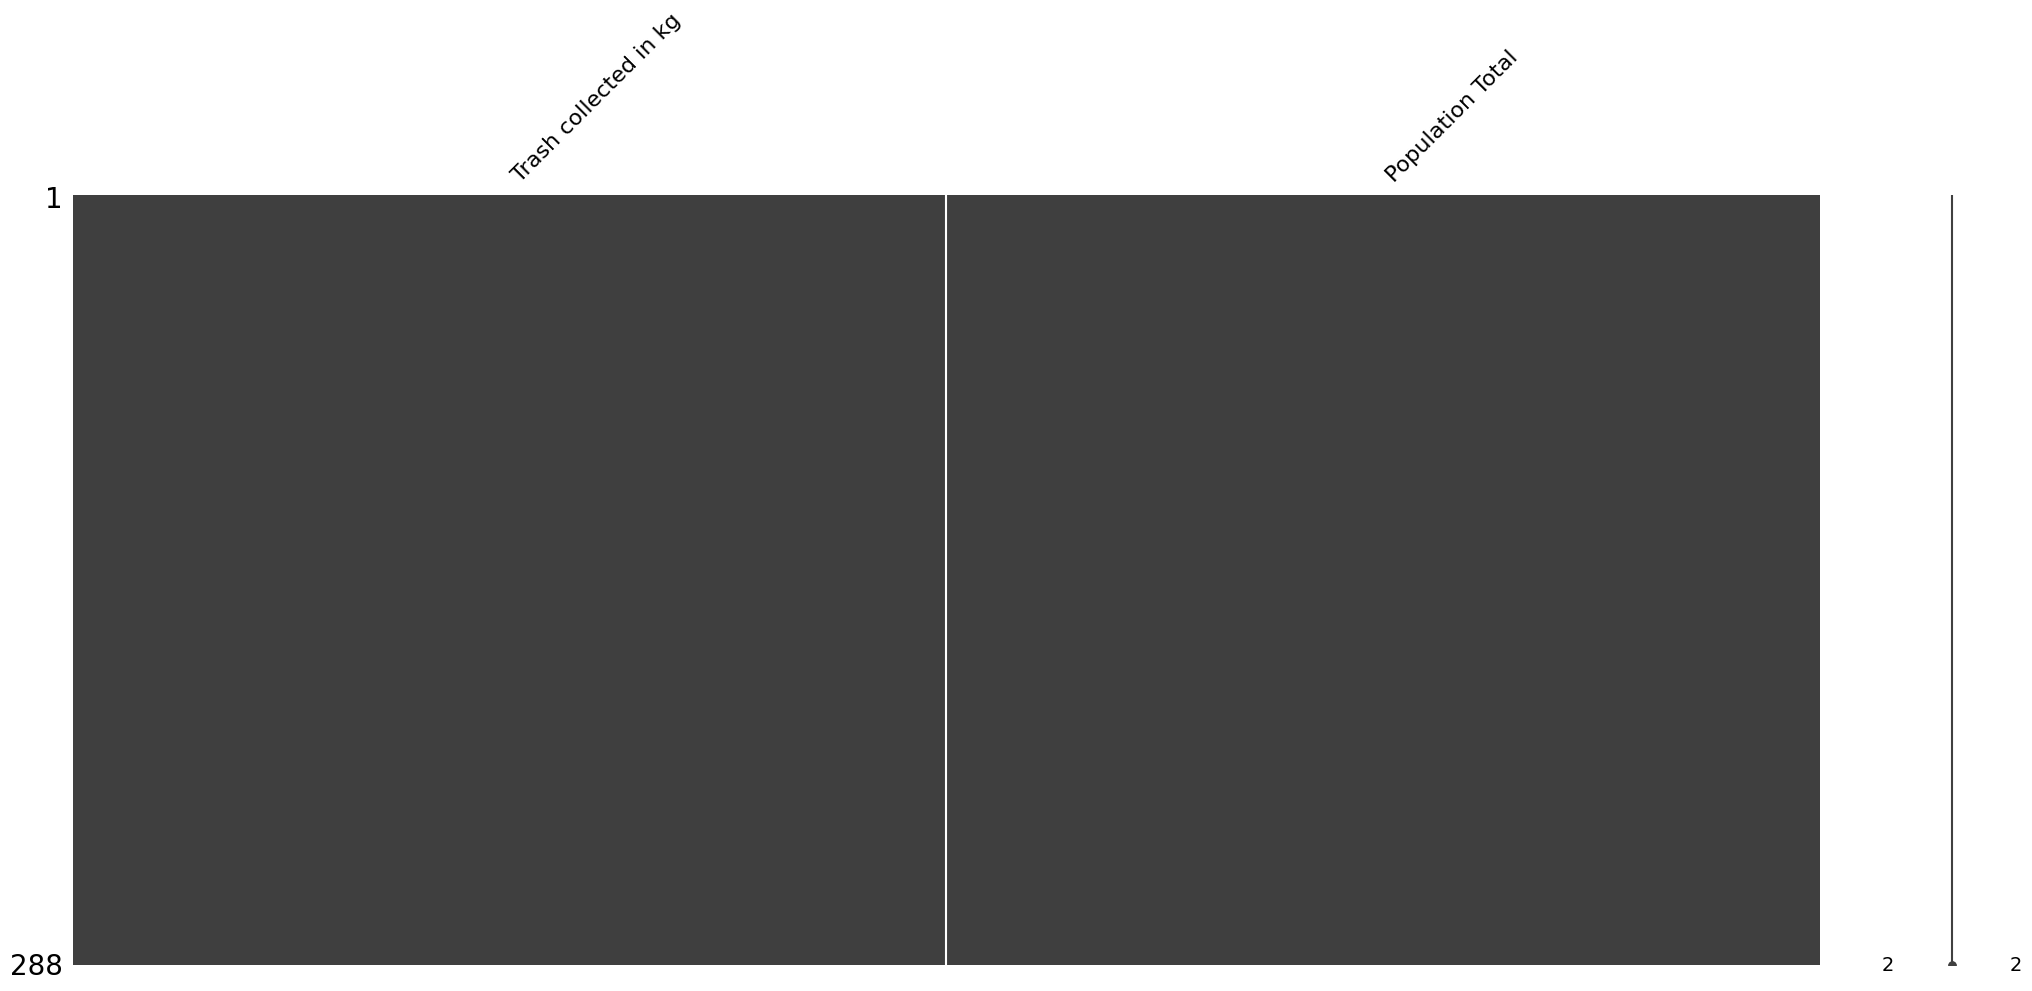

In [ ]:
msno.matrix(projeto[[dep,indep]])

In [ ]:
projeto[dep].describe()

count     288.000000
mean      473.046354
std       379.473016
min      -278.980000
25%       206.450000
50%       378.285000
75%       616.582500
max      1818.380000
Name: Trash collected in kg, dtype: float64

In [ ]:
projeto[indep].describe()

count    288.000000
mean     109.055556
std       55.238448
min      -43.000000
25%       71.250000
50%      104.000000
75%      140.000000
max      296.000000
Name: Population Total, dtype: float64

Text(0.5, 0, 'Trash collected in kg')

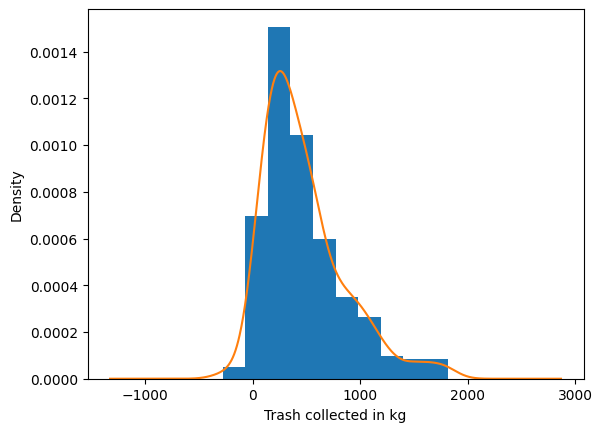

In [ ]:
ax = projeto[dep].plot.hist(density=True)
projeto[dep].plot.density(ax=ax)
ax.set_xlabel(dep)

Text(0.5, 0, 'Population Total')

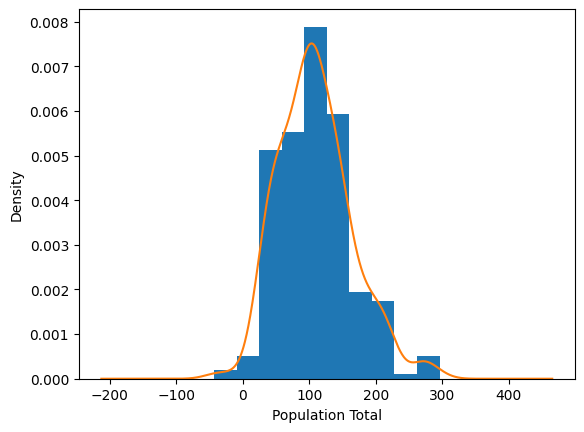

In [ ]:
ax = projeto[indep].plot.hist(density=True)
projeto[indep].plot.density(ax=ax)
ax.set_xlabel(indep)

(288, 1) (288, 1)


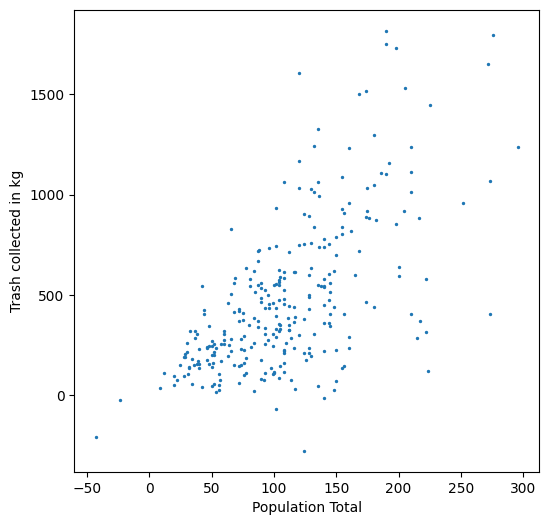

In [ ]:
x = projeto[indep].values.reshape(-1, 1)
y = projeto[dep].values.reshape(-1, 1)

print(x.shape, y.shape)

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=2)
plt.xlabel(indep)
plt.ylabel(dep)

plt.show()

<Axes: xlabel='Population Total', ylabel='Trash collected in kg'>

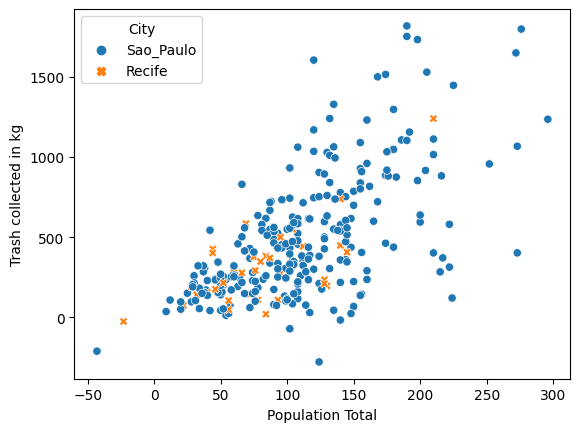

In [ ]:
sns.scatterplot(data=projeto, x=indep, y=dep, hue="City", style="City")

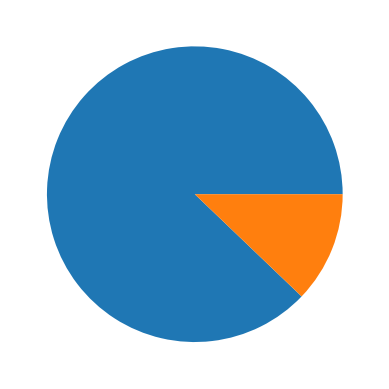

In [ ]:
plt.pie(projeto['City'].value_counts())
plt.show()

In [ ]:
projeto.value_counts('City')

City
Sao_Paulo    253
Recife        35
dtype: int64

In [ ]:
grupoA = [5]*30
grupoB = [5]*30
mediaA = []
quantilA = []
mediaB = []
quantilB = []
for i in range (30):
  grupoA[i] = projeto[dep].sample(frac=0.3).dropna()
  grupoB[i] = projeto[indep].sample(frac=0.3).dropna()


  mediaA.append(grupoA[i].mean())
  quantilA.append(grupoA[i].quantile(0.9))

  mediaB.append(grupoB[i].mean())
  quantilB.append(grupoB[i].quantile(0.9))

stat=0.966, p=0.435
A média do grupo A provavelmente segue uma Distribuição Normal
stat=0.969, p=0.523
A média do grupo B provavelmente segue uma Distribuição Normal


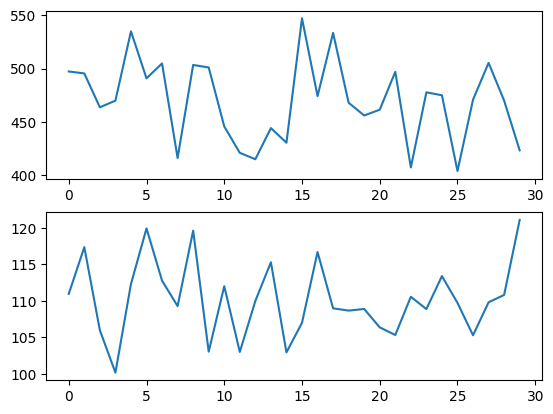

In [ ]:
plt.subplot(2,1,1)
plt.plot(mediaA)
data = mediaA
stat, p = shapiro(data)
print('stat=%.3f, p=%.3f' % (stat, p))

if p > 0.05:
	print('A média do grupo A provavelmente segue uma Distribuição Normal')
else:
	print('A média do grupo A provavelmente NÃO segue uma Distribuição Normal')

plt.subplot(2,1,2)
plt.plot(mediaB)
data = mediaB
stat, p = shapiro(data)
print('stat=%.3f, p=%.3f' % (stat, p))

if p > 0.05:
	print('A média do grupo B provavelmente segue uma Distribuição Normal')
else:
	print('A média do grupo B provavelmente NÃO segue uma Distribuição Normal')

plt.show()

In [ ]:
statistics.stdev(mediaA)

38.63818996887798

In [ ]:
statistics.stdev(mediaB)

5.268507135270928

stat=0.971, p=0.581
O percentil90 do grupo A provavelmente segue uma Distribuição Normal
stat=0.753, p=0.000
As variáveis do grupo A Provavelmente são Dependentes


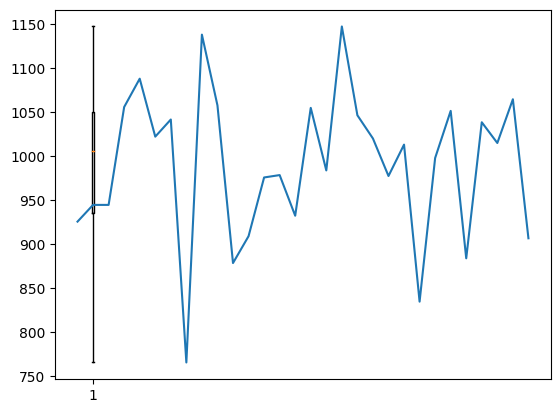

In [ ]:
plt.boxplot(quantilA)
plt.plot(quantilA)
data = quantilA
stat, p = shapiro(data)
print('stat=%.3f, p=%.3f' % (stat, p))

if p > 0.05:
	print('O percentil90 do grupo A provavelmente segue uma Distribuição Normal')
else:
	print('O percentil90 do grupo A provavelmente NÃO seguem uma Distribuição Normal')

data1 = quantilA
data2 = mediaA
stat, p = pearsonr(data1, data2)
print('stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
	print('As variáveis do grupo A Provavelmente são Independentes')
else:
	print('As variáveis do grupo A Provavelmente são Dependentes')

stat=0.978, p=0.761
As variáveis do grupo B provavelmente seguem uma Distribuição Normal
stat=0.671, p=0.000
As variáveis do grupo B são Provavelmente Dependentes


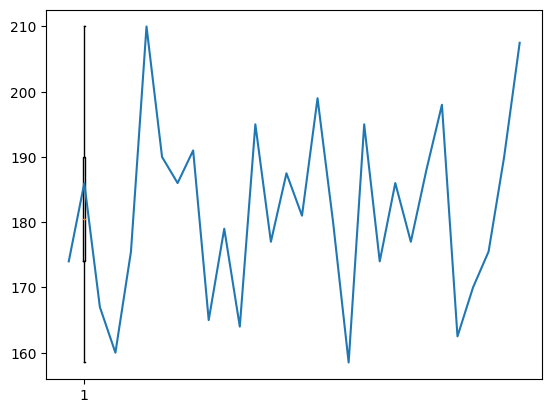

In [ ]:
plt.boxplot(quantilB)
plt.plot(quantilB)
data = quantilB
stat, p = shapiro(data)
print('stat=%.3f, p=%.3f' % (stat, p))

if p > 0.05:
	print('As variáveis do grupo B provavelmente seguem uma Distribuição Normal')
else:
	print('As variáveis do grupo B provavelmente NÃO seguem uma Distribuição Normal')

data1 = quantilB
data2 = mediaB
stat, p = pearsonr(data1, data2)
print('stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
	print('As variáveis do grupo B são Provavelmente Independentes')
else:
	print('As variáveis do grupo B são Provavelmente Dependentes')

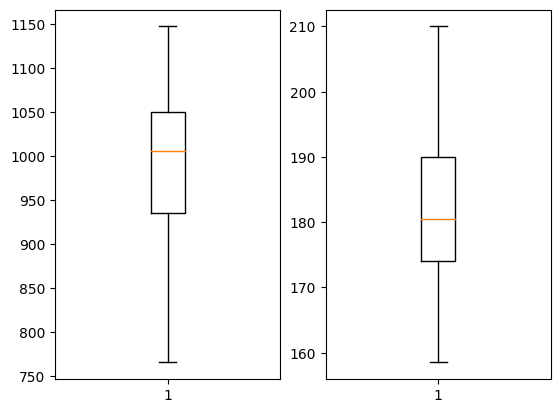

In [ ]:
plt.subplot(1,2,1)
plt.boxplot(quantilA)
plt.subplot(1,2,2)
plt.boxplot(quantilB)
plt.show()

In [ ]:
stat, p = f_oneway(grupoA[0],grupoB[0])

# Imprimindo os resultados
print("Estatística de teste F: {:.3f}".format(stat))
print("valor-p: {:.3f}".format(p))

if p < 0.05:
    print("Rejeitamos a hipótese nula.")
else:
    print("Não rejeitamos a hipótese nula.")

Estatística de teste F: 105.328
valor-p: 0.000
Rejeitamos a hipótese nula.


## Regressão Polinomial

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
class PolynomialRegression():
    def __init__(self, degree=2):
        self.degree = degree
        self.b = None

    def fit(self, x, y):
        powers = self.__compute_powers(x)

        b1 = np.linalg.inv(np.dot(powers.T, powers))
        b2 = np.dot(powers.T, y)
        self.b = np.dot(b1, b2)

    def predict(self, x):
        powers = self.__compute_powers(x)
        return np.dot(powers, self.b)

    def __compute_powers(self, x):
        x = x.ravel()
        powers = np.empty((x.shape[0], self.degree + 1))
        powers[:, 0] = np.ones(x.shape[0])
        powers[:, 1] = x

        for p in range(2, self.degree+1):
            powers[:, p] = x**p
        return powers

[[ 5.53671408e+01]
 [ 2.44676562e+00]
 [ 1.59372181e-02]
 [-3.65149827e-05]]


Text(0, 0.5, 'Trash collected in kg')

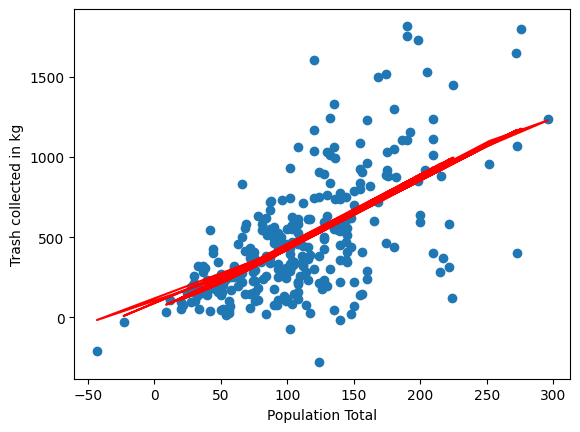

In [ ]:
reg = PolynomialRegression(degree=3)
reg.fit(x, y)

print(reg.b)

y_pred = reg.predict(x)
plt.scatter(x, y)
plt.plot(x, y_pred, color='red')
plt.xlabel(indep)
plt.ylabel(dep)

In [ ]:
r2 = r2_score(y,y_pred)
print("R-squared:", r2)

R-squared: 0.40319667033489603


# **Teste de Hipótese 2**

Baseado na quantidade de lixo coletada montar um modelo onde é possivel dizer se aquele lixo foi coletado a cada 1 ou 2 dias

In [ ]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay

In [ ]:
projeto['Daily'] = np.where(((projeto['Trash gathering interval/Days'] == 1) | (projeto['Trash gathering interval/Days'] == 2)), 1, 0)

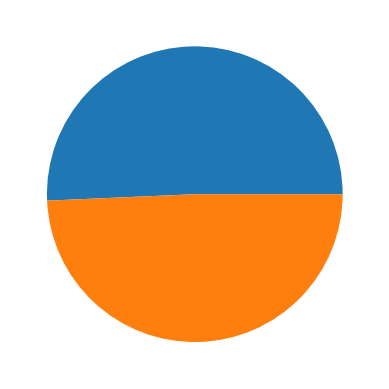

In [ ]:
plt.pie(projeto['Daily'].value_counts())
plt.show()

Optimization terminated successfully.
         Current function value: 0.644237
         Iterations 5


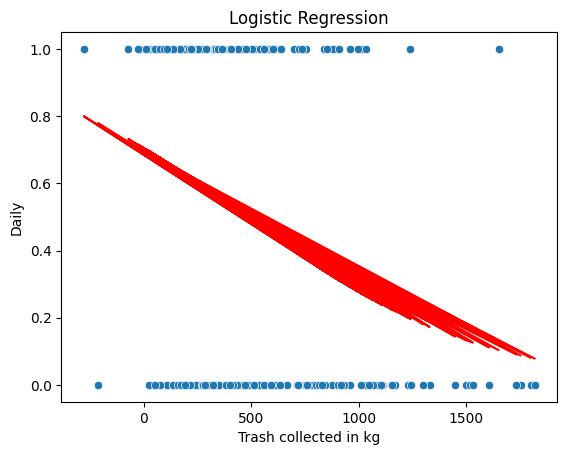

In [ ]:
classificador = 'Daily'
variavel = 'Trash collected in kg'
sns.scatterplot(x=variavel, y=classificador, data=projeto)

# Fit the logistic regression model
X = sm.add_constant(projeto[variavel])
y = projeto[classificador]
logit_model = sm.Logit(y, X)
logit_results = logit_model.fit()

# Get the predicted probabilities for the logistic regression curve
predicted_probs = logit_results.predict(X)

# Plot the logistic regression curve
plt.plot(projeto[variavel], predicted_probs, color='red')

# Set plot labels
plt.xlabel(variavel)
plt.ylabel(classificador)
plt.title('Logistic Regression')
plt.show()

In [ ]:

#define the predictor variables and the response variable
XOld = projeto[variavel].values.reshape(-1,1)
yOld = projeto[classificador]

#split the dataset into training (70%) and testing (30%) sets
X_train1,X_test1,y_train1,y_test1 = train_test_split(XOld,yOld,test_size=0.3,random_state=0)

#instantiate the model
log_regression = LogisticRegression()

#fit the model using the training data
log_regression.fit(X_train1,y_train1)
#define metrics
y_pred_proba = log_regression.predict_proba(X_test1)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test1,  y_pred_proba)
auc = metrics.roc_auc_score(y_test1, y_pred_proba)

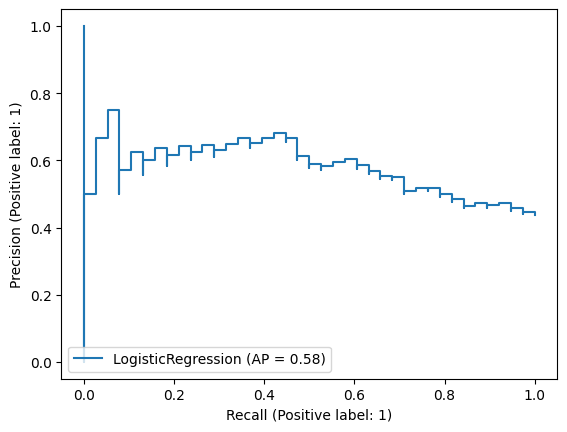

In [ ]:
PrecisionRecallDisplay.from_estimator(
   log_regression, X_test1, y_test1)

plt.show()

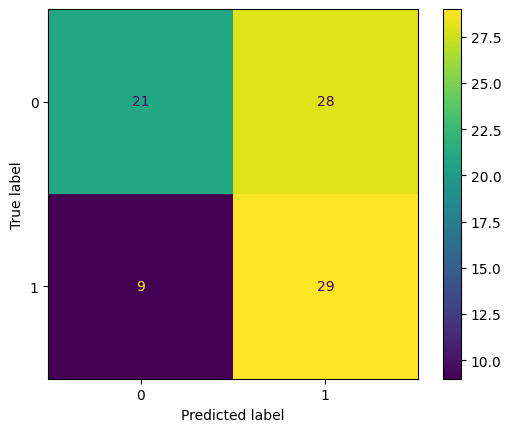

In [ ]:
cm = confusion_matrix(y_test1, log_regression.predict(X_test1))

cm_display = ConfusionMatrixDisplay(cm).plot()

F-Score é : 0.669


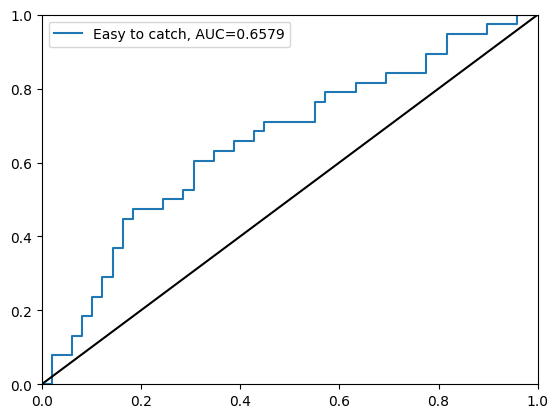

In [ ]:

#set up plotting area
plt.figure(0).clf()

#fit logistic regression model and plot ROC curve
model = LogisticRegression()
model.fit(X_train1, y_train1)
y_pred1 = model.predict_proba(X_test1)[:, 1]
fpr, tpr, _ = metrics.roc_curve(y_test1, y_pred1)
auc = round(metrics.roc_auc_score(y_test1, y_pred1), 4)
plt.plot(fpr,tpr,label="Easy to catch, AUC="+str(auc))

y_predf1 = model.predict(XOld)
F1 =f1_score(yOld, y_predf1,labels=[classificador])
print(f'F-Score é : {F1:.3f}')
x=np.linspace(0,100,101)
plt.plot(x,x,'k-') # identity line

plt.xlim(0,1)
plt.ylim(0,1)
plt.legend()

In [ ]:
projeto.to_csv('projetoFinal.csv',index=False)